# **Complaint Classification and Priority System**

#### Mounting the google drive to Colab for integrating with the Dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/Capestone Project 2/complaints_processed.csv'

## Importing Necessary Libraries

In [3]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_colwidth', None)
print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


In [4]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing called back dispute amount transaction rebillmerchandiserobert ca purchased thu posted wed purchased appears statement transaction rebill ca u followed see status case submitted documentation showing canceled order supposed submit refund called back speak manager case stated dispute ruled favor charge removed card capital one removed purchase bill purchase adjustmentmerchandiserobert j posted fri purchased appears statement purchase adjustment capital one recharges amount transaction rebillmerchandiserobert j purchased thu posted mon purchased appears statement transaction rebill called capital one requested recharge stated visa ruled case pretended remove purchase knew anything case manager ruling favor
1,1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria secret original credit comenity bank lower limit began charge overage fee along late fee began pay close attention card find limit also changed well incurring overage late fee reached company comenity bank stated would change credit limit original limit reached told summit payment account corrected comenity bank credit card impacted credit score plummeted negative status im currently paying price due corruption affected detrimental way debt due company charging overage fee well late fee even initial credit limit fluctuating tremendously company charge major fee account willing correct account nervous said attorney reason im reaching im employee company ruining credit plz help name contact info thank
2,2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account see court hearing several different government agency reporting well including branch put open account numerous fraudulent charge debit card connected account clearly due fact well fargo maintain clearly required encryption card keep secure adding damage request small claim lawsuit time take away running business branch required come branch multiple time get fraudulent charge removed actually present strong case proper consumer protection agency well fargo immediately barred issuing account debit card insure agency card adequate prevent fraudulent use also requesting punitive treble damage sum hour take work handle lawsuit along legal cost filing lawsuit county small claim court today well fargo outrageous fraudulent conduct clearly warrant punitive damage also sharing every possible consumer protection agency find would think well fargo enough adverse publicity fraudulent conduct last year introduce small claim suit clearly establishing well fargo established business practice fraud customer ca judge really need reminded might want immediately run bonus payment legal department
3,3,credit_reporting,payment history missing credit report specialized loan s

In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing called back dispute amount transaction rebillmerchandiserobert ca purchased thu posted wed purchased appears statement transaction rebill ca u followed see status case submitted documentation showing canceled order supposed submit refund called back speak manager case stated dispute ruled favor charge removed card capital one removed purchase bill purchase adjustmentmerchandiserobert j posted fri purchased appears statement purchase adjustment capital one recharges amount transaction rebillmerchandiserobert j purchased thu posted mon purchased appears statement transaction rebill called capital one requested recharge stated visa ruled case pretended remove purchase knew anything case manager ruling favor
1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria secret original credit comenity bank lower limit began charge overage fee along late fee began pay close attention card find limit also changed well incurring overage late fee reached company comenity bank stated would change credit limit original limit reached told summit payment account corrected comenity bank credit card impacted credit score plummeted negative status im currently paying price due corruption affected detrimental way debt due company charging overage fee well late fee even initial credit limit fluctuating tremendously company charge major fee account willing correct account nervous said attorney reason im reaching im employee company ruining credit plz help name contact info thank
2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account see court hearing several different government agency reporting well including branch put open account numerous fraudulent charge debit card connected account clearly due fact well fargo maintain clearly required encryption card keep secure adding damage request small claim lawsuit time take away running business branch required come branch multiple time get fraudulent charge removed actually present strong case proper consumer protection agency well fargo immediately barred issuing account debit card insure agency card adequate prevent fraudulent use also requesting punitive treble damage sum hour take work handle lawsuit along legal cost filing lawsuit county small claim court today well fargo outrageous fraudulent conduct clearly warrant punitive damage also sharing every possible consumer protection agency find would think well fargo enough adverse publicity fraudulent conduct last year introduce small claim suit clearly establishing well fargo established business practice fraud customer ca judge really need reminded might want immediately run bonus payment legal department
3,credit_reporting,payment history missing credit report specialized loan servicing sl made mi

## Data Understanding & Initial Inspection

#### First we will create the copy of the original datadet to avoid any data loss.

In [6]:
data = df.copy()

In [7]:
data.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing called back dispute amount transaction rebillmerchandiserobert ca purchased thu posted wed purchased appears statement transaction rebill ca u followed see status case submitted documentation showing canceled order supposed submit refund called back speak manager case stated dispute ruled favor charge removed card capital one removed purchase bill purchase adjustmentmerchandiserobert j posted fri purchased appears statement purchase adjustment capital one recharges amount transaction rebillmerchandiserobert j purchased thu posted mon purchased appears statement transaction rebill called capital one requested recharge stated visa ruled case pretended remove purchase knew anything case manager ruling favor
1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria secret original credit comenity bank lower limit began charge overage fee along late fee began pay close attention card find limit also changed well incurring overage late fee reached company comenity bank stated would change credit limit original limit reached told summit payment account corrected comenity bank credit card impacted credit score plummeted negative status im currently paying price due corruption affected detrimental way debt due company charging overage fee well late fee even initial credit limit fluctuating tremendously company charge major fee account willing correct account nervous said attorney reason im reaching im employee company ruining credit plz help name contact info thank
2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account see court hearing several different government agency reporting well including branch put open account numerous fraudulent charge debit card connected account clearly due fact well fargo maintain clearly required encryption card keep secure adding damage request small claim lawsuit time take away running business branch required come branch multiple time get fraudulent charge removed actually present strong case proper consumer protection agency well fargo immediately barred issuing account debit card insure agency card adequate prevent fraudulent use also requesting punitive treble damage sum hour take work handle lawsuit along legal cost filing lawsuit county small claim court today well fargo outrageous fraudulent conduct clearly warrant punitive damage also sharing every possible consumer protection agency find would think well fargo enough adverse publicity fraudulent conduct last year introduce small claim suit clearly establishing well fargo established business practice fraud customer ca judge really need reminded might want immediately run bonus payment legal department
3,credit_reporting,payment history missing credit report specialized loan servicing sl made mi

In [8]:
# Shape of dataset
print("Dataset Shape:", data.shape)

Dataset Shape: (162421, 2)


In [9]:
# Column names
print("\nColumns:")
print(data.columns)


Columns:
Index(['product', 'narrative'], dtype='object')


In [10]:
# Data types + non-null values
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162421 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB
None


In [11]:
# Missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
product       0
narrative    10
dtype: int64


#### There are 10 missing values in the datset and we will remove them.

In [12]:
# Check original shape
print("Original Shape:", data.shape)

Original Shape: (162421, 2)


In [13]:
# Remove missing values
data.dropna(inplace=True)

In [14]:
# Checking the shape after reomving the missing values.
print("Original Shape:", data.shape)

Original Shape: (162411, 2)


In [15]:
# Duplicate rows
print("\nDuplicate Rows:", data.duplicated().sum())


Duplicate Rows: 37735


In [16]:
# Remove duplicate rows
data.drop_duplicates(inplace=True)

In [17]:
# After removing the duplicates checking the shape of the dataset.
data.shape

(124676, 2)

#### We can see a drastic change after removing the duplicates but duplicates are of no use.

## Exploratory Data Analysis (EDA)

In [18]:
# Number of categories
print("Total Categories:", data['product'].nunique())

# Top 10 categories
print("\nTop 10 Complaint Categories:")
print(data['product'].value_counts().head(10))

Total Categories: 5

Top 10 Complaint Categories:
product
credit_reporting       56303
debt_collection        21117
mortgages_and_loans    18759
credit_card            15024
retail_banking         13473
Name: count, dtype: int64


### Insight: It shows the category distribution of the products.

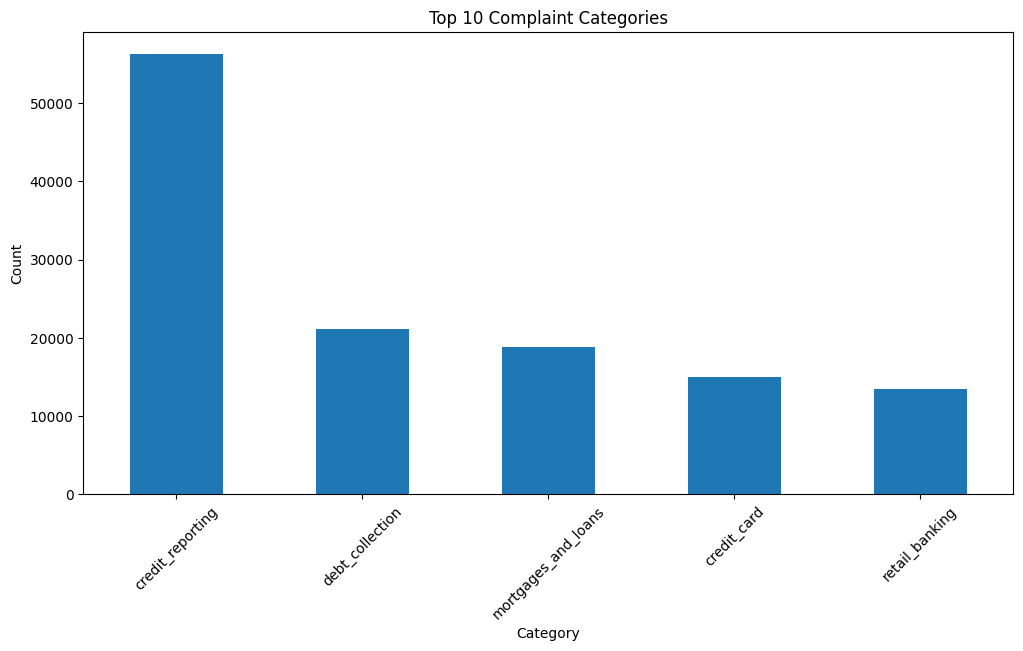

In [19]:
top_categories = data['product'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_categories.plot(kind='bar')
plt.title("Top 10 Complaint Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Insight: The category 'credit_reporting' has the highest number of complaints in the dataset, indicating that many users face issues related to credit reports, credit scores, or incorrect financial reporting records.

In [20]:
# Create text length column
data['text_length'] = data['narrative'].apply(len)

print(data['text_length'].describe())

count    124676.000000
mean        633.359484
std         832.511639
min           3.000000
25%         219.000000
50%         414.000000
75%         752.000000
max       20596.000000
Name: text_length, dtype: float64


### We created a column "text_length" in ehich we have calculated the text lenght of each row.

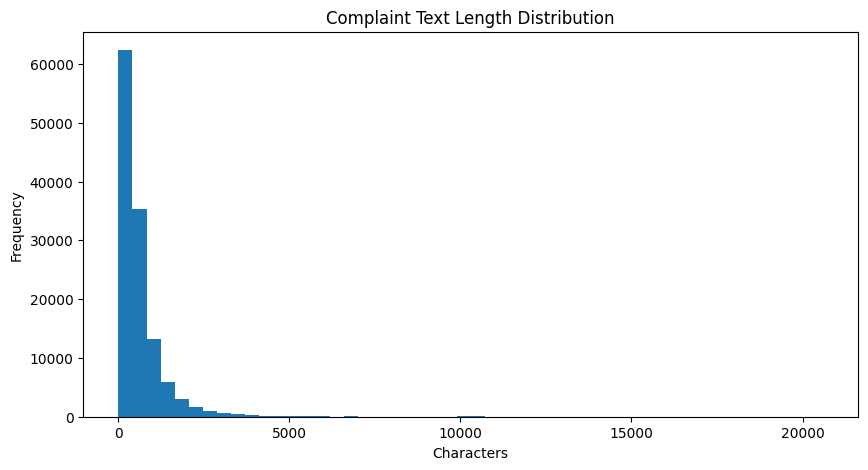

In [21]:
plt.figure(figsize=(10,5))
plt.hist(data['text_length'], bins=50)
plt.title("Complaint Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

### Insight:
Most complaint narratives in the dataset are short to medium in length, indicating that users usually describe their issues concisely.  
A small number of complaints are very lengthy, showing that some users provide highly detailed explanations of their problems.  
The text length distribution is positively skewed, where most complaints are short and only a few are exceptionally long.


## Word CLoud for each complaint

In [22]:
!pip install wordcloud

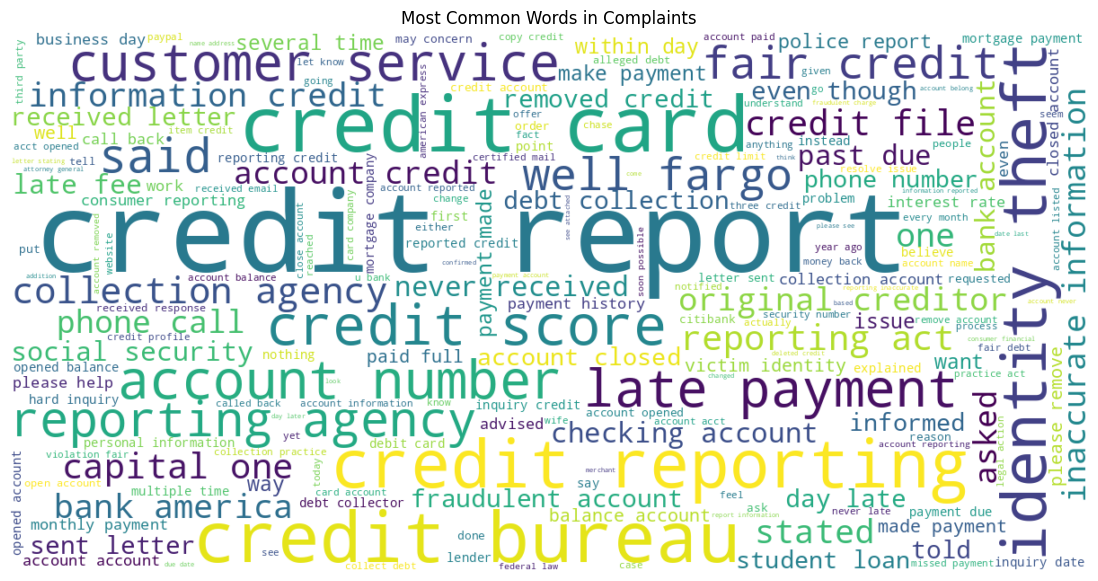

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all complaint text
text = " ".join(data['narrative'].astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200
).generate(text)

# Show
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Complaints")
plt.show()

## Text Preprocessing (NLP Data Cleaning Phase)

In [24]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [25]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [26]:
data['cleaned_text'] = data['narrative'].apply(clean_text)

data[['narrative', 'cleaned_text']].head()

,narrative,cleaned_text
0,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing called back dispute amount transaction rebillmerchandiserobert ca purchased thu posted wed purchased appears statement transaction rebill ca u followed see status case submitted documentation showing canceled order supposed submit refund called back speak manager case stated dispute ruled favor charge removed card capital one removed purchase bill purchase adjustmentmerchandiserobert j posted fri purchased appears statement purchase adjustment capital one recharges amount transaction rebillmerchandiserobert j purchased thu posted mon purchased appears statement transaction rebill called capital one requested recharge stated visa ruled case pretended remove purchase knew anything case manager ruling favor,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing called back dispute amount transaction rebillmerchandiserobert ca purchased thu posted wed purchased appears statement transaction rebill ca u followed see status case submitted documentation showing canceled order supposed submit refund called back speak manager case stated dispute ruled favor charge removed card capital one removed purchase bill purchase adjustmentmerchandiserobert j posted fri purchased appears statement purchase adjustment capital one recharges amount transaction rebillmerchandiserobert j purchased thu posted mon purchased appears statement transaction rebill called capital one requested recharge stated visa ruled case pretended remove purchase knew anything case manager ruling favor
1,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria secret original credit comenity bank lower limit began charge overage fee along late fee began pay close attention card find limit also changed well incurring overage late fee reached company comenity bank stated would change credit limit original limit reached told summit payment account corrected comenity bank credit card impacted credit score plummeted negati

### We can see that both the columns are looking same because the data was already processed.

In [27]:
data.sample(5)

,product,narrative,text_length,cleaned_text
25762,mortgages_and_loans,hi name dealt regional finance texas branch yr point service prior loan never late payment paid early adversly effected covid lost form income notified attempted make arrangemnets submitted bank statement proof drastically reduced income one attempt month recieving call denied reduction payment make worse wife harrasssed married wife knew nothing loan included reference dealing regional finance yr prior requested leave personal loan yet repeatedly attempted involve causing really bad home situation explained corporate office situation gotten worse intimidating using wife harrassment unjust wife never discussed finance one another seperate bank account involoved personal matter caused undue stress household offerede pay interest gainfully employed yet met wife pay dont know else point,794,hi name dealt regional finance texas branch yr point service prior loan never late payment paid early adversly effected covid lost form income notified attempted make arrangemnets submitted bank statement proof drastically reduced income one attempt month recieving call denied reduction payment make worse wife harrasssed married wife knew nothing loan included reference dealing regional finance yr prior requested leave personal loan yet repeatedly attempted involve causing really bad home situation explained corporate office situation gotten worse intimidating using wife harrassment unjust wife never discussed finance one another seperate bank account involoved personal matter caused undue stress household offerede pay interest gainfully employed yet met wife pay dont know else point
31360,credit_reporting,process looking buying new home discouraged find credit dropped immensely hindering ability close home writing due non compliance transunion failed remove information affiliated personal detail inaccurate challenged past strongly believe violation fcra fair credit reporting act outright refusing uphold law,307,process looking buying new home discouraged find credit dropped immensely hindering ability close home writing due non compliance transunion failed remove information affiliated personal detail inaccurate challenged past strongly believe violation fcra fair credit reporting act outright refusing uphold law
35370,retail_banking,attempted open checking account b told issue given information order report report came reported information inquiry retail info nothing would prohibit opening checking account,176,attempted open checking account b told issue given information order report report came reported information inquiry retail info nothing would prohibit opening checking account
150509,retail_banking,still living opened account checking saving suntrust truist online made husband secondary account holder option transfered account would set move bank sent temporary check deposit slip well atm card shortly receiving item received letter stating account closed due rule regulation deposit money returned letter called fraud department bank told information available moved contacted suntrust truist bank open new account told closed account could reopened question could open new account answer first probing speaking various department hour phone finally got consumer department told u could open account husband could received information back office called fraud department questioning revealed would even able give husband access account husband got call another check back office fraud department told suntrust allow husband open account banned life business suntrust told fraud department refused speak husband willing give explanation issue allow address defend possible falsity,985,still living opened account checking saving suntrust truist online made husband secondary account holder option transfered account would set move bank sent temporary check deposit slip well atm card shortly receiving item received letter stating account closed due rule regulation deposit money returne

## Data Transformation & Feature Engineering

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['cleaned_text'])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (124676, 5000)


#### Label-Encoding Target Column

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(data['product'])

print("Total Categories:", len(le.classes_))
print("Sample Labels:", le.classes_[:10])

Total Categories: 5
Sample Labels: ['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']


#### Train Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (99740, 5000)
X_test Shape: (24936, 5000)


## Model Building & Training

#### Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [32]:
y_pred_lr = lr_model.predict(X_test)

## Model Evaluation

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Accuracy: 0.8496952197625922

Classification Report:

                     precision    recall  f1-score   support

        credit_card       0.80      0.78      0.79      3005
   credit_reporting       0.87      0.90      0.89     11261
    debt_collection       0.81      0.76      0.78      4223
mortgages_and_loans       0.85      0.84      0.84      3752
     retail_banking       0.86      0.89      0.87      2695

           accuracy                           0.85     24936
          macro avg       0.84      0.83      0.83     24936
       weighted avg       0.85      0.85      0.85     24936



#### Naive Bayes model

In [34]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8136028232274624


#### Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=30
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7732595444337504


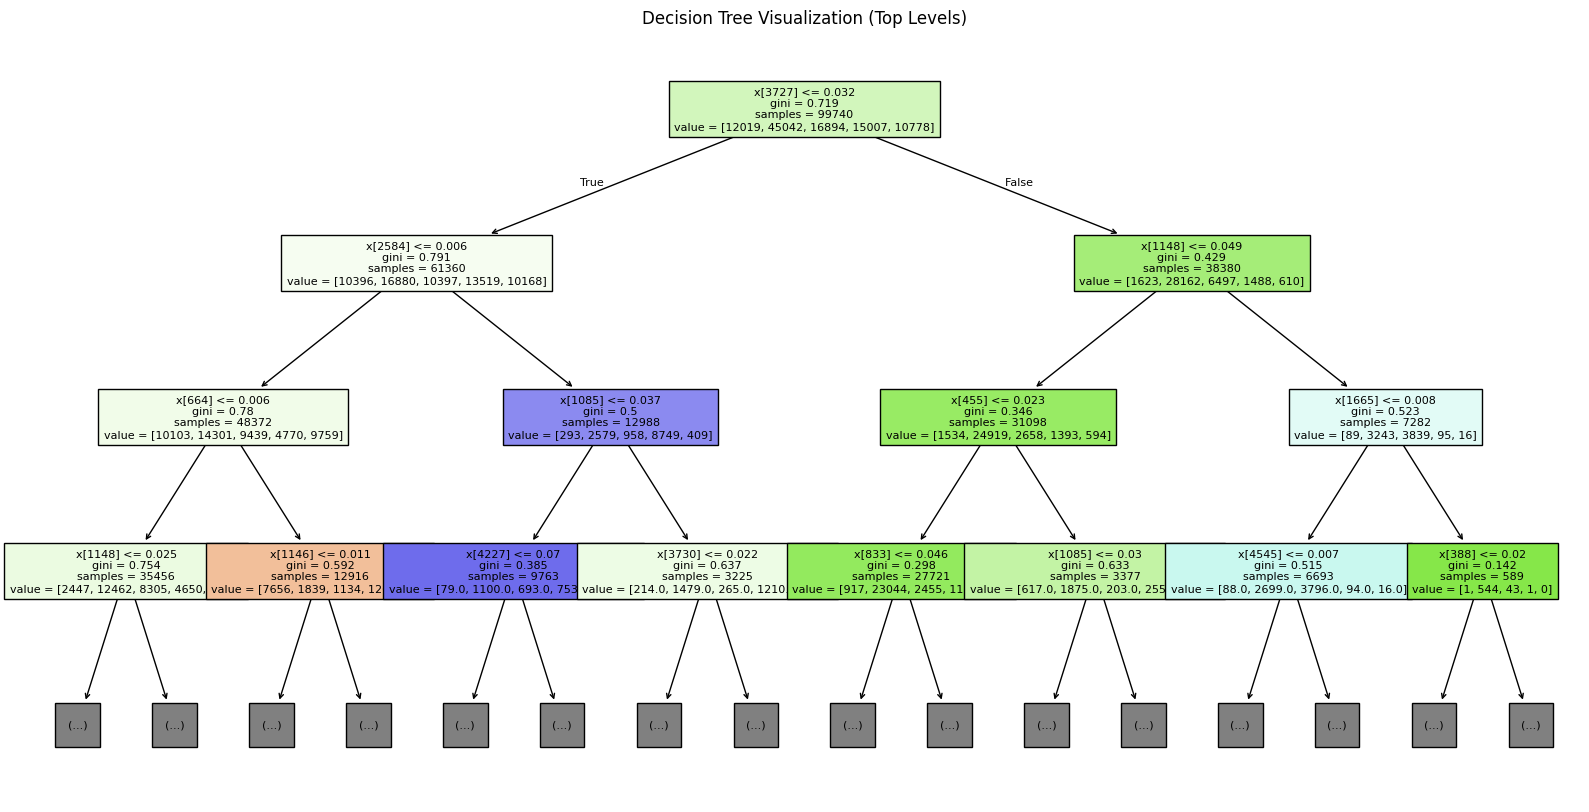

In [39]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    max_depth=3,     # show first 3 levels only
    fontsize=8
)

plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

#### Comparing all the models

In [38]:
print("Logistic Regression :", accuracy_score(y_test, y_pred_lr))
print("Naive Bayes        :", accuracy_score(y_test, y_pred_nb))
print("Decision Tree      :", accuracy_score(y_test, y_pred_dt))

Logistic Regression : 0.8496952197625922
Naive Bayes        : 0.8136028232274624
Decision Tree      : 0.7732595444337504


## Hyperparameter Tuning (Logistic Regression)

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Parameter combinations
param_grid = {
    'C': [0.1, 1, 5, 10],   # controls regularization strength
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]   # maximum training iterations
}

# Grid Search CV
grid_lr = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)   # fitting the grid search cv

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross Validation Score:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Best Cross Validation Score: 0.8450972428745054


In [41]:
best_lr = grid_lr.best_estimator_

y_pred_tuned = best_lr.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Tuned Accuracy: 0.8496952197625922

Classification Report:

                     precision    recall  f1-score   support

        credit_card       0.80      0.78      0.79      3005
   credit_reporting       0.87      0.90      0.89     11261
    debt_collection       0.81      0.76      0.78      4223
mortgages_and_loans       0.85      0.84      0.84      3752
     retail_banking       0.86      0.89      0.87      2695

           accuracy                           0.85     24936
          macro avg       0.84      0.83      0.83     24936
       weighted avg       0.85      0.85      0.85     24936



## Model Deployment & User Interface (Streamlit)

In [42]:
import joblib

# Save best final model
joblib.dump(best_lr, "complaint_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save Label Encoder
joblib.dump(le, "label_encoder.pkl")

print("All files saved successfully.")

All files saved successfully.


In [43]:
%%writefile app.py

import streamlit as st
import joblib
from textblob import TextBlob

# Load saved files
model = joblib.load("complaint_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

# Title
st.title("FIR / Complaint Classification System")
st.subheader("AI-Based Complaint Category, Sentiment & Priority Predictor")

# Input box
user_input = st.text_area("Enter Complaint Text")

# Priority function
def get_priority(text, sentiment):
    text = text.lower()

    urgent_words = ['fraud', 'stolen', 'harassment', 'threat', 'scam', 'urgent']

    if any(word in text for word in urgent_words):
        return "High"
    elif sentiment < 0:
        return "Medium"
    else:
        return "Low"

# Predict button
if st.button("Predict"):

    if user_input.strip() != "":

        # Category Prediction
        vector = tfidf.transform([user_input])
        pred = model.predict(vector)
        category = le.inverse_transform(pred)[0]

        # Sentiment
        sentiment_score = TextBlob(user_input).sentiment.polarity

        if sentiment_score < 0:
            sentiment = "Negative"
        elif sentiment_score == 0:
            sentiment = "Neutral"
        else:
            sentiment = "Positive"

        # Priority
        priority = get_priority(user_input, sentiment_score)

        # Output
        st.success("Prediction Complete")

        st.write("### Complaint Category:", category)
        st.write("### Sentiment:", sentiment)
        st.write("### Priority Level:", priority)

    else:
        st.warning("Please enter complaint text.")

Writing app.py


In [44]:
!pip install streamlit pyngrok textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 28.8 MB/s eta 0:00:00


In [46]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦⠧⠇⠏⠋⠙Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.12.213.222:8501

  Stopping...
^C
